# Clustering Analysis using K-Means and DBSCAN on EastWest Airlines Dataset
### Objective
**The objective of this assignment is to:**

Understand clustering techniques and unsupervised learning.

Implement K-Means and DBSCAN clustering algorithms.

Perform data preprocessing and exploratory data analysis.

Evaluate clustering performance using internal metrics.

Compare clustering results and interpret the generated clusters.

# Import Libraries

In [1]:
# Basic Libraries
import numpy as np
import pandas as pd
# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing
from sklearn.preprocessing import StandardScaler
# Clustering Algorithms
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
# Evaluation Metrics
from sklearn.metrics import silhouette_score
# For Nearest Neighbors Plot
from sklearn.neighbors import NearestNeighbors
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Loading dataset

In [5]:
# Load dataset
path = '/content/EastWestAirlines.xlsx'
# Read Excel file
df = pd.read_excel(path, sheet_name = 'data')
# Display first five rows
print(df.head())

   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
4    5    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
4           26               2077                4               6935       1  


# Exploratory Data Analysis

In [6]:
# Basic EDA
# Shape of dataset
print('Dataset Shape:', df.shape)
# Column names
print('\nColumns in Dataset:')
print(df.columns)
# Dataset Information
print('\nDataset Information:')
print(df.info())
# Statistical Summary
print('\nStatistical Summary:')
print(df.describe())


Dataset Shape: (3999, 12)

Columns in Dataset:
Index(['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award

In [7]:
# Missing values
print(df.isnull().sum())

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


# Interpretation
The dataset contains either very few or no missing values. Missing values, if present, must be handled
before clustering.


In [9]:
# Filling missing values with median
for column in df.columns:
    if df[column].dtype != 'object':
        df[column].fillna(df[column].median(), inplace=True)

# Detecting & removing outliers

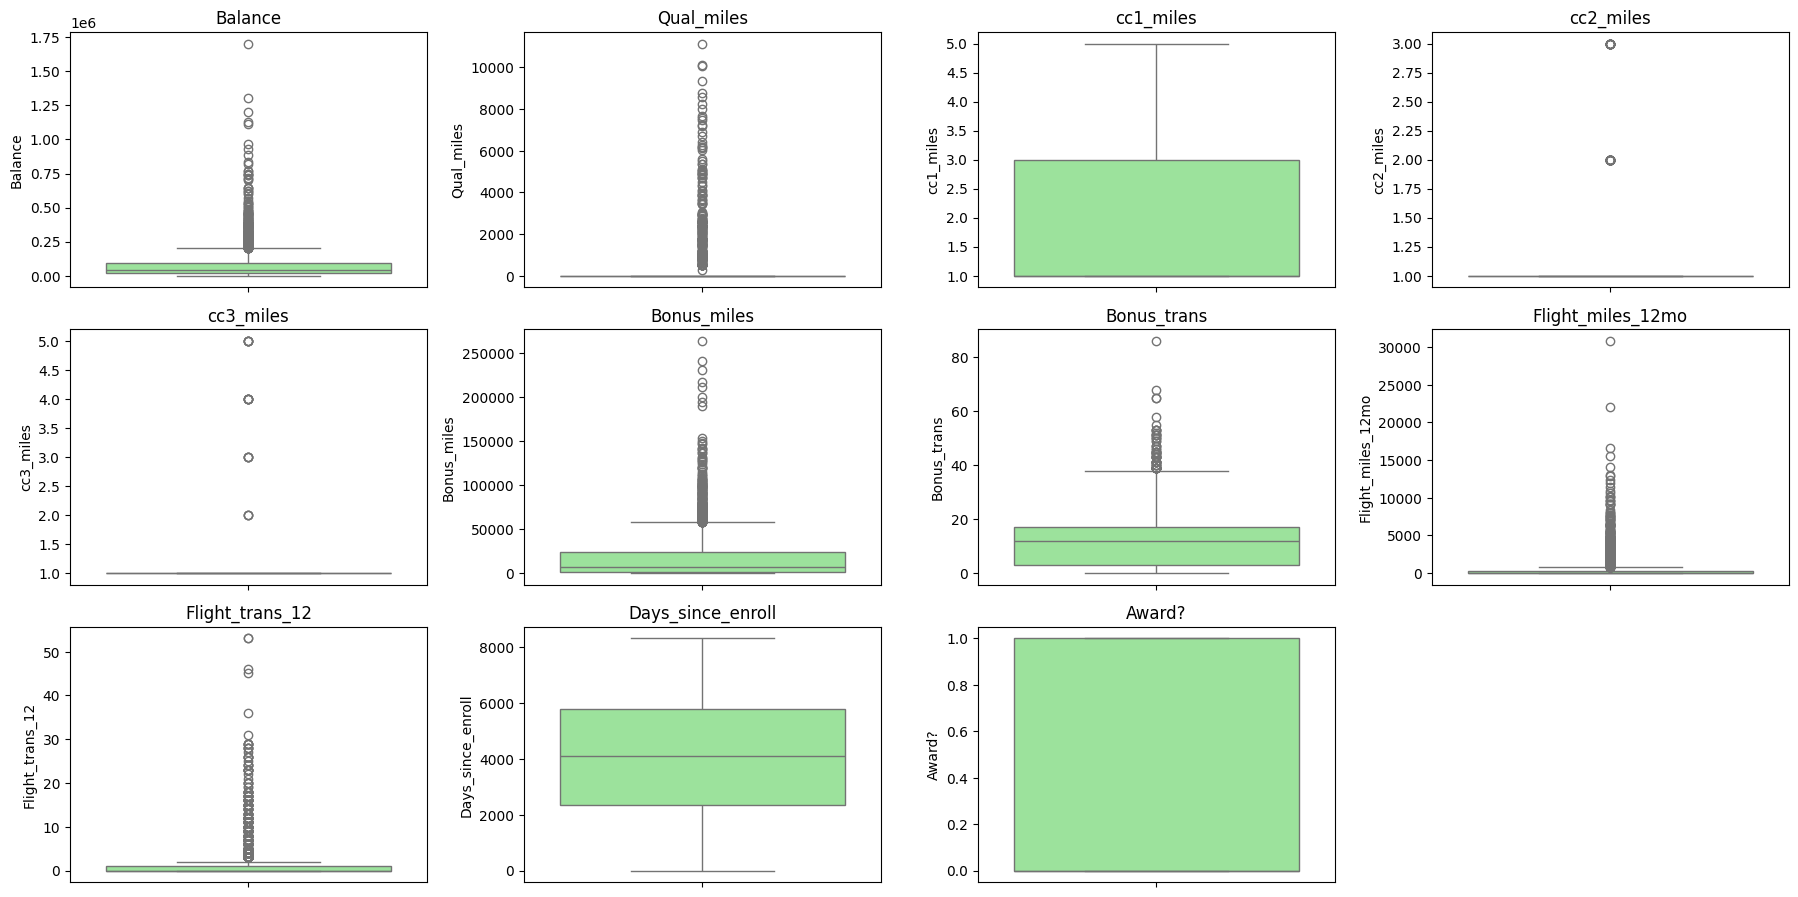

In [11]:
# Boxplots for outlier detection
plt.figure(figsize=(18,12))
for i, column in enumerate(df.columns[1:], 1):
    plt.subplot(4,4,i)
    sns.boxplot(y=df[column], color='lightgreen')
    plt.title(column)
plt.tight_layout()
plt.show()

# Interpretation
Several variables contain outliers, especially customer-related numerical features.

In [12]:
# Removing outliers using IQR
for column in df.select_dtypes(include=np.number).columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Feature Scaling-
### Clustering algorithms are distance-based methods. Therefore, feature scaling is essential.

In [13]:
# Removing ID column if present
if 'ID#' in df.columns:
   df = df.drop('ID#', axis=1)
# Standardization
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
# Convert to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
print(scaled_df.head())


    Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0 -0.351730         0.0  -0.571271        0.0        0.0    -0.663819   
1 -0.573510         0.0  -0.571271        0.0        0.0    -0.659907   
2 -0.022485         0.0  -0.571271        0.0        0.0    -0.287037   
3 -0.684862         0.0  -0.571271        0.0        0.0    -0.632715   
4 -0.643890         0.0  -0.571271        0.0        0.0    -0.680421   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0    -0.922006                0.0              0.0           1.566499     0.0  
1    -0.784064                0.0              0.0           1.551190     0.0  
2    -0.508181                0.0              0.0           1.582766     0.0  
3    -0.922006                0.0              0.0           1.543535     0.0  
4    -1.059947                0.0              0.0           1.538751     0.0  


# Visual Exploratory Data Analysis

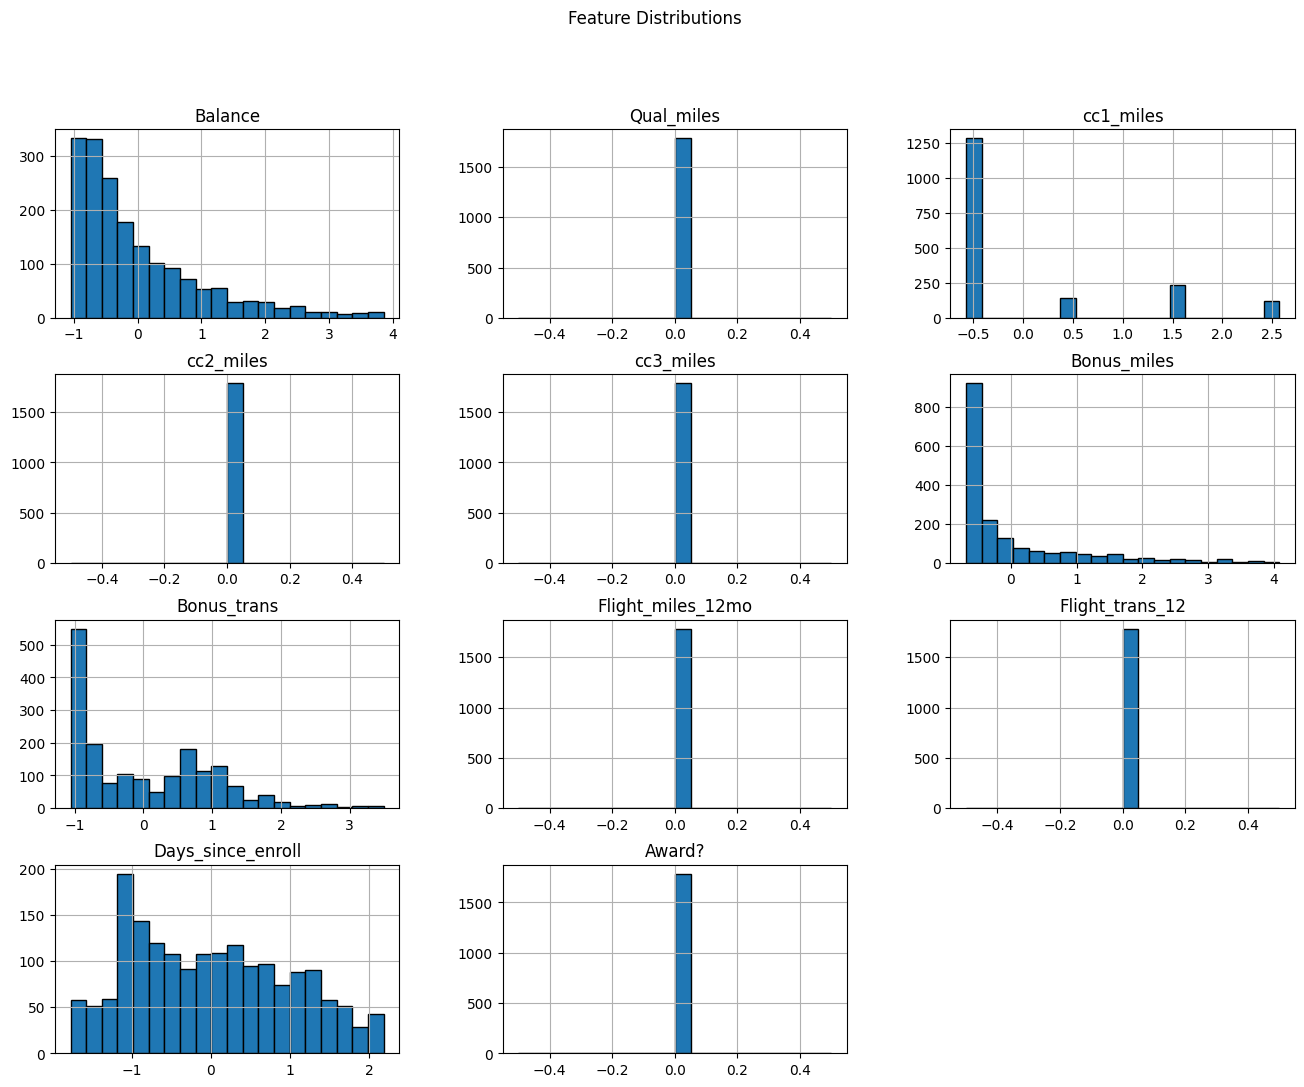

In [14]:
# Histograms
scaled_df.hist(figsize=(16,12), bins=20, edgecolor='black')
4
plt.suptitle('Feature Distributions')
plt.show()

# Interpretation
The histograms reveal the distribution and spread of the airline customer data.

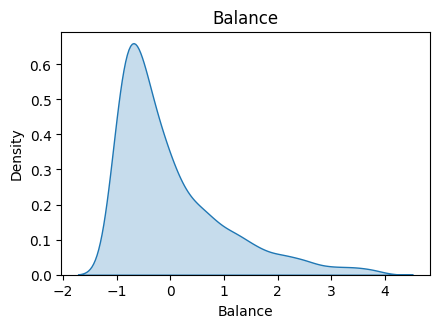

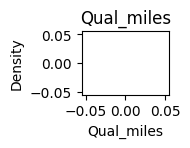

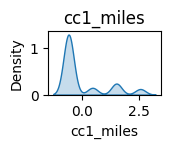

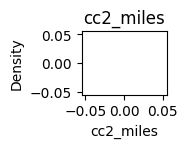

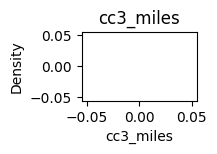

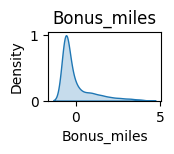

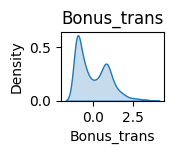

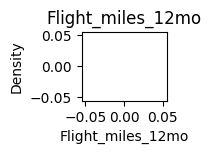

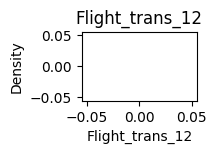

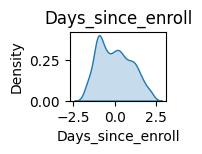

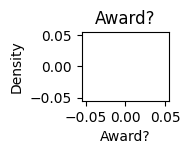

In [15]:
# Density plots
plt.figure(figsize=(16,12))
for i, column in enumerate(scaled_df.columns, 1):
    plt.subplot(4,4,i)
    sns.kdeplot(scaled_df[column], fill=True)
    plt.title(column)
    plt.tight_layout()
    plt.show()

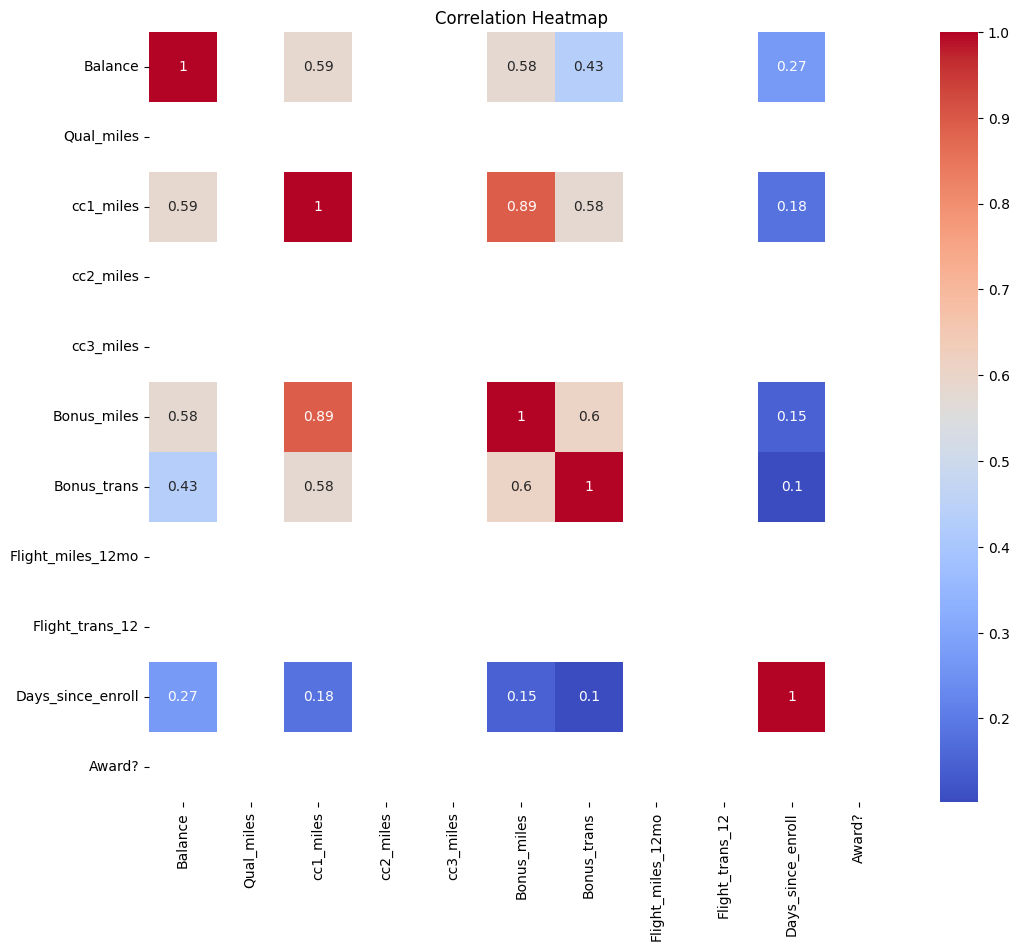

In [16]:
# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(scaled_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


# Interpretation
Strong correlations indicate relationships between customer travel behavior features.
Highly correlated features may influence clustering formation.


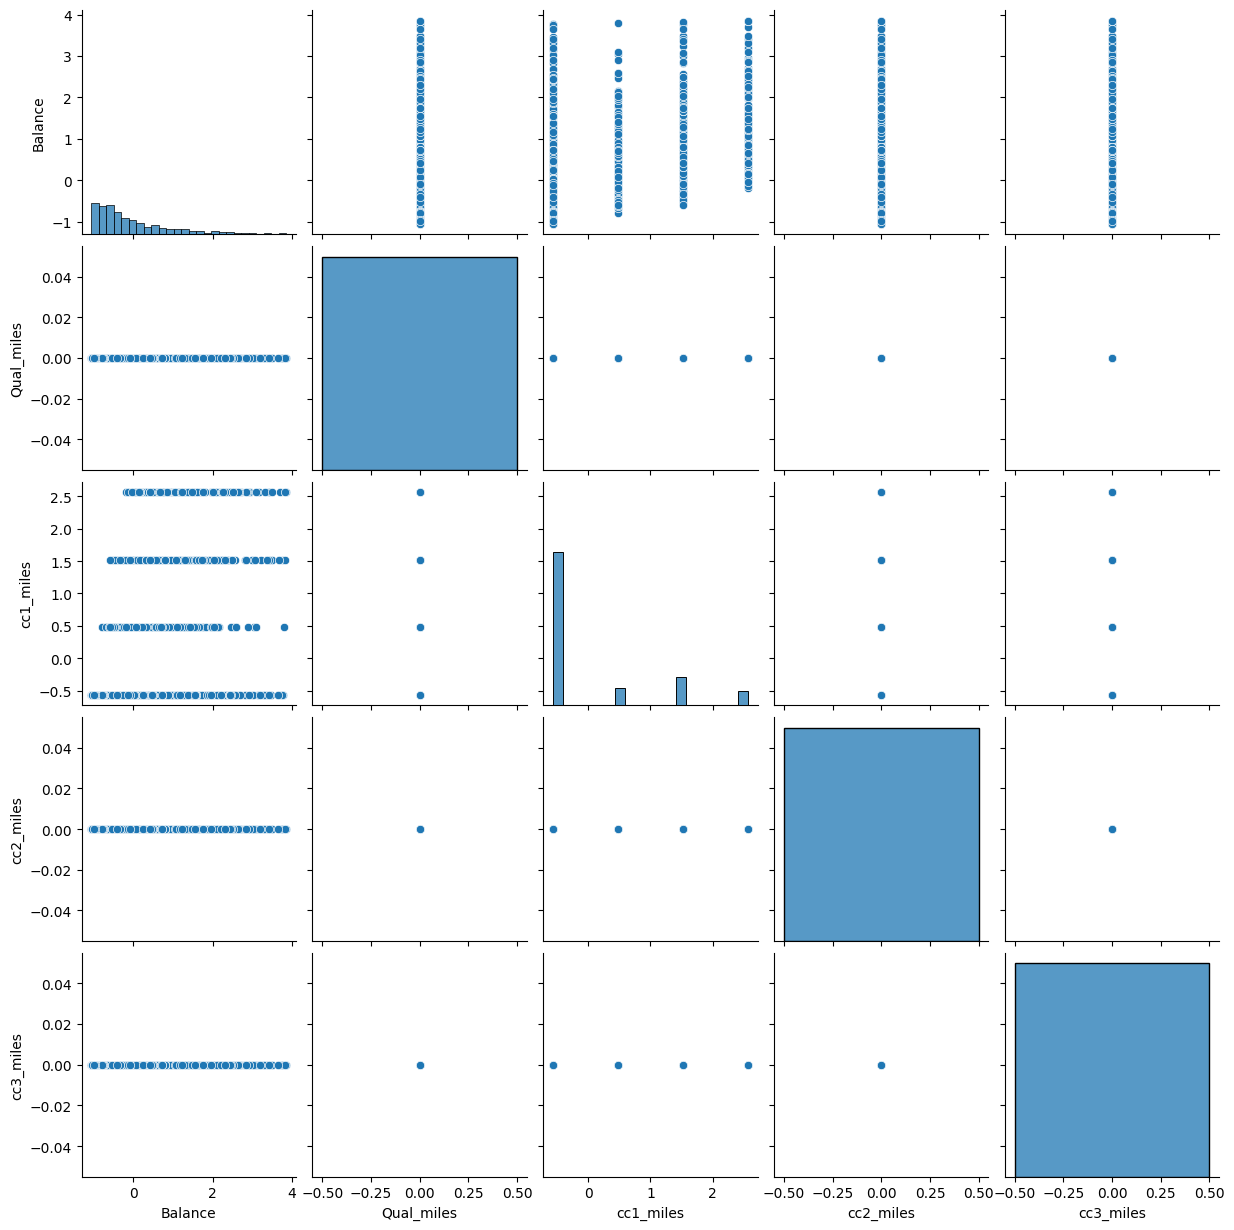

In [17]:
# Pairplot for selected features
sns.pairplot(scaled_df.iloc[:, :5])
plt.show()

# Interpretation
Pairplots help identify hidden patterns and natural groupings within the dataset

# Implementing K-Means Clustering

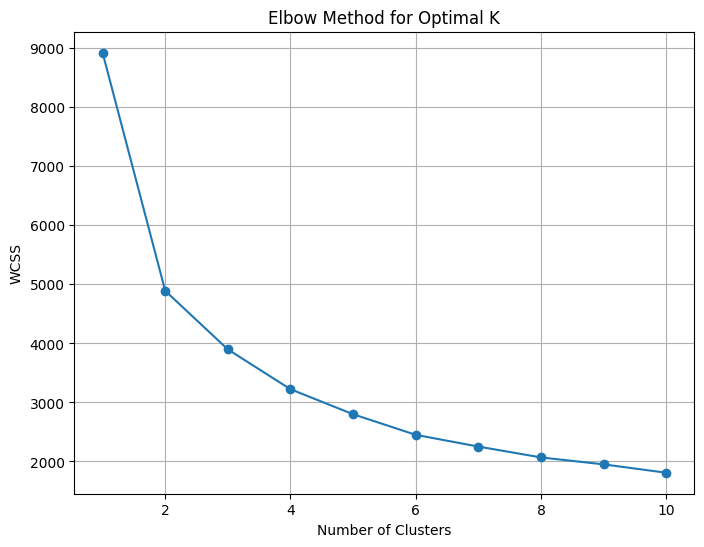

In [19]:
# Finding Optimal Number of Clusters using Elbow Method
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)
# Plot Elbow Curve
plt.figure(figsize=(8,6))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.grid()
plt.show()


# Interpretation
The elbow point indicates the optimal number of clusters where adding more clusters gives diminishing
returns.


In [20]:
# Applying K-Means
kmeans_model = KMeans(n_clusters=4, random_state=42)
kmeans_clusters = kmeans_model.fit_predict(scaled_df)
# Add cluster labels
scaled_df['KMeans_Cluster'] = kmeans_clusters

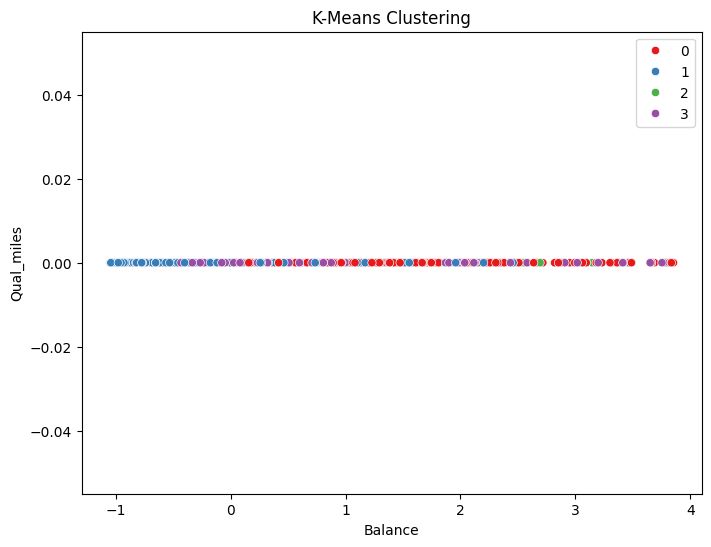

In [21]:
# Visualizing K-Means Clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
x=scaled_df.iloc[:,0],
y=scaled_df.iloc[:,1],
hue=kmeans_clusters,
palette='Set1'
)
plt.title('K-Means Clustering')
plt.xlabel(scaled_df.columns[0])
plt.ylabel(scaled_df.columns[1])
plt.show()

# Interpretation
Different colors represent distinct customer clusters identified by K-Means.

In [22]:
# Evaluating K-Means Clustering
# Silhouette Score
kmeans_silhouette = silhouette_score(
scaled_df.drop('KMeans_Cluster', axis=1),
kmeans_clusters
)
print('K-Means Silhouette Score:', kmeans_silhouette)

K-Means Silhouette Score: 0.3153322636550039


# Interpretation
A higher silhouette score indicates better-defined and well-separated clusters.

In [23]:
# K Means cluster analysis
# Cluster means
kmeans_analysis = scaled_df.groupby('KMeans_Cluster').mean()
print(kmeans_analysis)

                 Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
KMeans_Cluster                                                          
0               1.237255         0.0   1.836378        0.0        0.0   
1              -0.553019         0.0  -0.562338        0.0        0.0   
2              -0.336446         0.0  -0.539352        0.0        0.0   
3               0.196339         0.0  -0.064779        0.0        0.0   

                Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
KMeans_Cluster                                                                 
0                  1.714087     1.040693                0.0              0.0   
1                 -0.540901    -0.713446                0.0              0.0   
2                 -0.524800    -0.623413                0.0              0.0   
3                 -0.006697     1.011040                0.0              0.0   

                Days_since_enroll  Award?  
KMeans_Cluster                      

# Insights from K-Means Clusters
Some customer groups may represent frequent travelers.

Certain clusters may contain high-spending premium customers.

Other clusters may represent occasional or budget travelers.

Clustering helps identify customer segmentation strategies.

#  Implementing DBSCAN Clustering


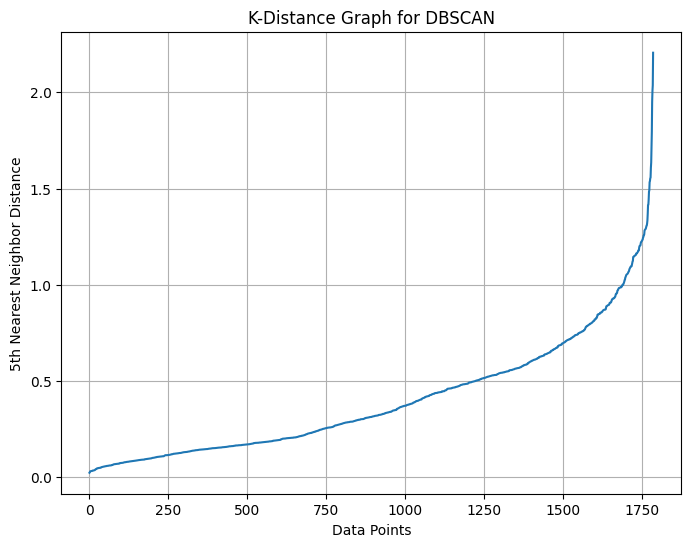

In [24]:
# Finding Optimal Epsilon using K-Distance Graph
# Nearest neighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(scaled_df.drop('KMeans_Cluster', axis=1))
distances, indices = neighbors_fit.kneighbors(
scaled_df.drop('KMeans_Cluster', axis=1)
)
# Sort distances
sorted_distances = np.sort(distances[:,4])
# Plot K-distance graph
plt.figure(figsize=(8,6))
plt.plot(sorted_distances)
plt.xlabel('Data Points')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-Distance Graph for DBSCAN')
plt.grid()
plt.show()

# Interpretation
The point where the graph sharply increases suggests a suitable epsilon value.

In [25]:
# Applying DBSCAN
dbscan_model = DBSCAN(eps=1.5, min_samples=5)
dbscan_clusters = dbscan_model.fit_predict(
scaled_df.drop('KMeans_Cluster', axis=1)
)
# Add DBSCAN clusters
scaled_df['DBSCAN_Cluster'] = dbscan_clusters

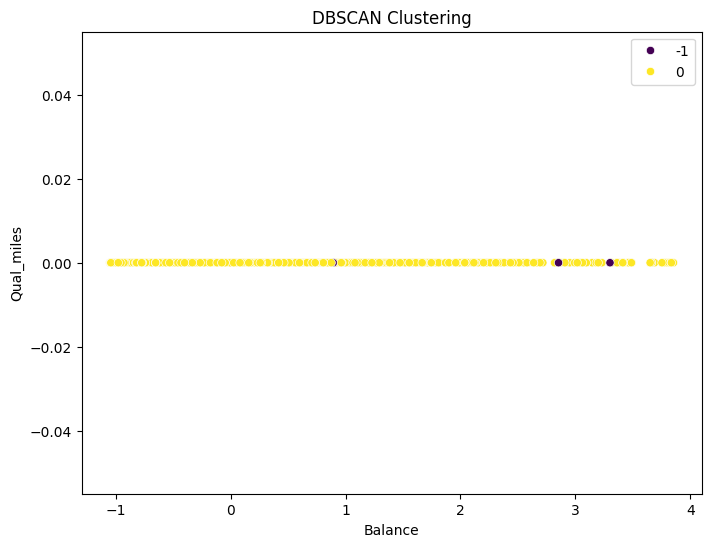

In [26]:
#  Visualizing DBSCAN Clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
x=scaled_df.iloc[:,0],
y=scaled_df.iloc[:,1],
hue=dbscan_clusters,
palette='viridis'
)
plt.title('DBSCAN Clustering')
plt.xlabel(scaled_df.columns[0])
plt.ylabel(scaled_df.columns[1])
plt.show()

# Interpretation
DBSCAN identifies dense regions and can classify some points as noise/outliers.


In [28]:
# Evaluating DBSCAN Clustering
# Remove noise points (-1)
valid_points = dbscan_clusters != -1
# Silhouette Score
if len(set(dbscan_clusters[valid_points])) > 1:
    dbscan_silhouette = silhouette_score(
    scaled_df.drop(['KMeans_Cluster', 'DBSCAN_Cluster'], axis=1)
    [valid_points],
    dbscan_clusters[valid_points]
    )
    print('DBSCAN Silhouette Score:', dbscan_silhouette)
else:
    print('DBSCAN did not form enough clusters for silhouette evaluation.')

DBSCAN did not form enough clusters for silhouette evaluation.


## Re-running DBSCAN with New Parameters

Based on the previous results, we need to adjust the DBSCAN parameters (`eps` and `min_samples`) to find more meaningful clusters. Here, you can specify new values to experiment with.

In [29]:
# @title Adjust DBSCAN Parameters
new_eps = 0.5 # @param {type:"number"}
new_min_samples = 10 # @param {type:"integer"}

In [30]:
# Applying DBSCAN with new parameters
dbscan_model_new = DBSCAN(eps=new_eps, min_samples=new_min_samples)
dbscan_clusters_new = dbscan_model_new.fit_predict(
    scaled_df.drop(['KMeans_Cluster', 'DBSCAN_Cluster'], axis=1)
)

# Add new DBSCAN clusters to the DataFrame
# Drop the old DBSCAN_Cluster column if it exists to avoid conflicts
if 'DBSCAN_Cluster' in scaled_df.columns:
    scaled_df = scaled_df.drop(columns=['DBSCAN_Cluster'])
scaled_df['DBSCAN_Cluster'] = dbscan_clusters_new

print(f"DBSCAN applied with eps={new_eps} and min_samples={new_min_samples}.")
print(f"Number of clusters found (excluding noise): {len(set(dbscan_clusters_new)) - (1 if -1 in dbscan_clusters_new else 0)}")
print(f"Number of noise points (-1): {np.sum(dbscan_clusters_new == -1)}")

DBSCAN applied with eps=0.5 and min_samples=10.
Number of clusters found (excluding noise): 5
Number of noise points (-1): 637


## Visualizing New DBSCAN Clusters

Let's visualize the clusters formed with the new parameters. Remember that DBSCAN can label points as noise (-1), which will be shown as a distinct color if present.

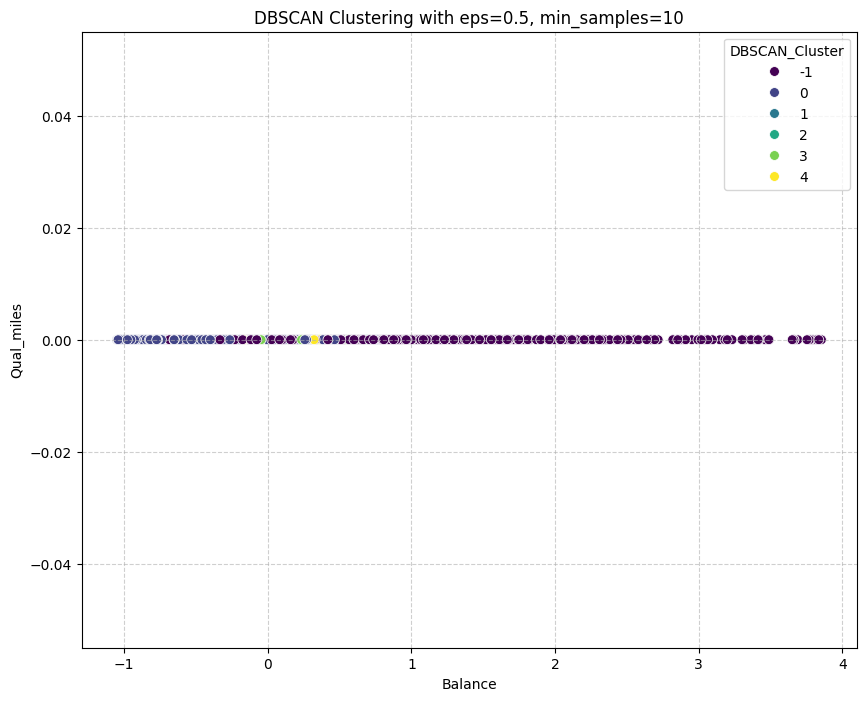

In [31]:
# Visualizing the new DBSCAN Clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=scaled_df.iloc[:, 0], # Using the first feature for x-axis
    y=scaled_df.iloc[:, 1], # Using the second feature for y-axis
    hue=scaled_df['DBSCAN_Cluster'],
    palette='viridis',
    legend='full', # Show legend for all clusters
    s=50 # Point size
)
plt.title(f'DBSCAN Clustering with eps={new_eps}, min_samples={new_min_samples}')
plt.xlabel(scaled_df.columns[0])
plt.ylabel(scaled_df.columns[1])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Evaluating New DBSCAN Clusters

Now, let's evaluate the new DBSCAN clustering using the Silhouette Score. We will exclude noise points (cluster -1) for this evaluation, as they are not part of any defined cluster.

In [32]:
# Evaluating DBSCAN Clustering with new parameters

# Remove noise points (-1) for silhouette score calculation
valid_points_new = dbscan_clusters_new != -1

# Check if there are enough valid clusters for silhouette evaluation
# Need at least 2 clusters and more than 1 point in total after removing noise
if len(set(dbscan_clusters_new[valid_points_new])) > 1 and np.sum(valid_points_new) > 1:
    dbscan_silhouette_new = silhouette_score(
        scaled_df.drop(['KMeans_Cluster', 'DBSCAN_Cluster'], axis=1)[valid_points_new],
        dbscan_clusters_new[valid_points_new]
    )
    print(f'New DBSCAN Silhouette Score: {dbscan_silhouette_new:.4f}')
else:
    print('DBSCAN with new parameters did not form enough distinct clusters for silhouette evaluation (excluding noise).')

New DBSCAN Silhouette Score: 0.0644


# Comparison of K-Means and DBSCAN

In [36]:
if 'comparison' not in locals():
    comparison = pd.DataFrame({
        'Algorithm': ['K-Means', 'DBSCAN'],
        'Silhouette Score': [kmeans_silhouette, dbscan_silhouette_new]
    })
else:
    comparison.loc[comparison['Algorithm'] == 'DBSCAN', 'Silhouette Score'] = dbscan_silhouette_new

print('\nSilhouette Score Comparison:')
print(comparison)


Silhouette Score Comparison:
  Algorithm  Silhouette Score
0   K-Means          0.315332
1    DBSCAN          0.064365


### Silhouette Score Comparison

Let's visualize the Silhouette Scores to clearly see the performance difference between K-Means and DBSCAN with the new parameters.

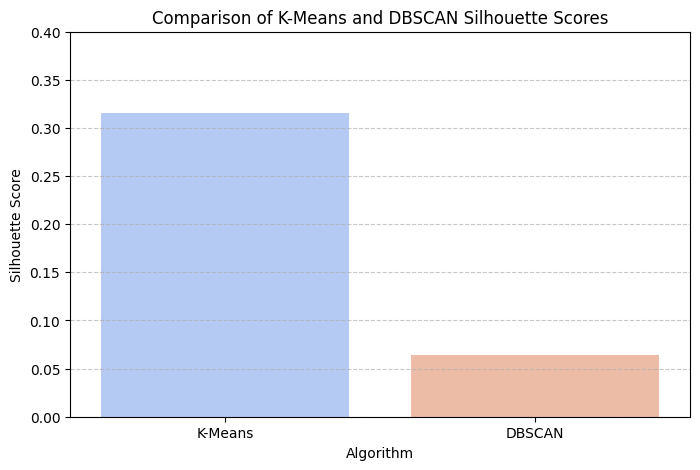

In [37]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Algorithm', y='Silhouette Score', data=comparison, palette='coolwarm')
plt.title('Comparison of K-Means and DBSCAN Silhouette Scores')
plt.ylabel('Silhouette Score')
plt.ylim(0, 0.4) # Set a reasonable y-limit based on the scores
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Visual Comparison of K-Means and DBSCAN Clusters

Now, let's visualize the clusters generated by both algorithms side-by-side to understand their spatial distribution and differences.

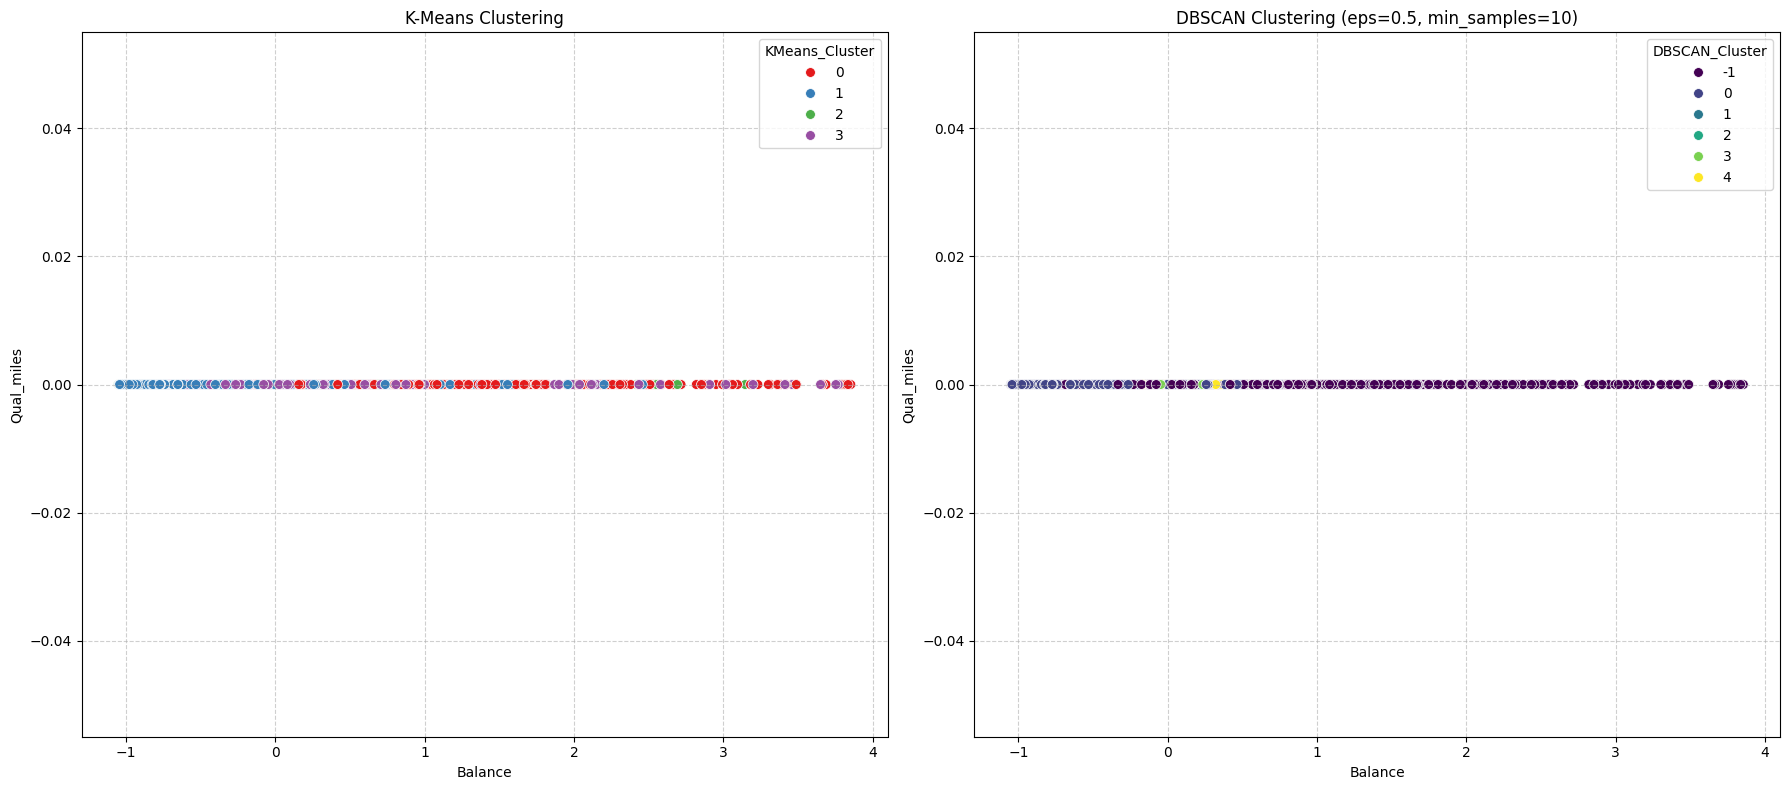

In [38]:
plt.figure(figsize=(18, 8))

# Plot K-Means Clusters
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(
    x=scaled_df.iloc[:, 0],
    y=scaled_df.iloc[:, 1],
    hue=scaled_df['KMeans_Cluster'],
    palette='Set1',
    legend='full',
    s=50
)
plt.title('K-Means Clustering')
plt.xlabel(scaled_df.columns[0])
plt.ylabel(scaled_df.columns[1])
plt.grid(True, linestyle='--', alpha=0.6)

# Plot DBSCAN Clusters
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(
    x=scaled_df.iloc[:, 0],
    y=scaled_df.iloc[:, 1],
    hue=scaled_df['DBSCAN_Cluster'],
    palette='viridis',
    legend='full',
    s=50
)
plt.title(f'DBSCAN Clustering (eps={new_eps}, min_samples={new_min_samples})')
plt.xlabel(scaled_df.columns[0])
plt.ylabel(scaled_df.columns[1])
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretation of Comparison

*   **Silhouette Scores:** K-Means currently shows a significantly higher Silhouette Score, indicating better-defined and more separated clusters compared to DBSCAN with the chosen parameters.
*   **Visual Distribution:** Observe the differences in how each algorithm groups data points and handles noise. K-Means creates spherical clusters, while DBSCAN identifies arbitrarily shaped clusters and explicitly marks noise points (-1).

This comparison highlights that K-Means, in this specific configuration, yielded more coherent and distinguishable clusters based on the silhouette metric. DBSCAN, while powerful for identifying dense regions and outliers, may require more fine-tuning of its `eps` and `min_samples` parameters to achieve comparable or superior results for this dataset.

| Feature                    | K-Means                             | DBSCAN                                  |
| :------------------------- | :---------------------------------- | :-------------------------------------- |
| **Cluster Number**         | Requires number of clusters beforehand | Automatically identifies clusters       |
| **Outlier Sensitivity**    | Sensitive to outliers               | Robust to outliers                      |
| **Cluster Shape**          | Assumes spherical clusters          | Detects arbitrary-shaped clusters       |
| **Computational Speed**    | Faster for large datasets           | Computationally intensive               |
| **Data Type Suitability**  | Works well with compact clusters    | Works well with noisy data / arbitrary shapes |

# Interpretation of Results
###K-Means
**Strengths:**
* Easy to implement
* Computationally efficient
* Produces compact clusters

**Weaknesses:**
* Sensitive to initialization
* Sensitive to outliers
* Requires predefining number of clusters
###DBSCAN
**Strengths:**
* Detects noise and outliers
* Handles irregular cluster shapes
* Does not require predefined number of clusters

**Weaknesses:**
* Sensitive to epsilon parameter
* Performance decreases in varying-density datasets
* More computationally expensive

# Feature Engineering Enhancement
Feature engineering can further improve clustering quality

In [39]:
# Example interaction feature
scaled_df['Balance_Miles'] = (
scaled_df.iloc[:,0] * scaled_df.iloc[:,1]
)


# Hyperparameter Tuning Enhancement

In [40]:
# Tuning K-Means
# Trying different K values
for k in range(2,10):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(
    scaled_df.drop(['KMeans_Cluster', 'DBSCAN_Cluster'], axis=1)
    )
    score = silhouette_score(
    scaled_df.drop(['KMeans_Cluster', 'DBSCAN_Cluster'], axis=1),
    labels
    )
    print(f'Clusters: {k}, Silhouette Score: {score}')

Clusters: 2, Silhouette Score: 0.47161379459987435
Clusters: 3, Silhouette Score: 0.3125567081861358
Clusters: 4, Silhouette Score: 0.3153322636550039
Clusters: 5, Silhouette Score: 0.3279884369654
Clusters: 6, Silhouette Score: 0.32569342998322764
Clusters: 7, Silhouette Score: 0.31602253210539294
Clusters: 8, Silhouette Score: 0.3232239172401989
Clusters: 9, Silhouette Score: 0.31904926789741206


In [42]:
# Tuning DB Scan
# Trying different epsilon values
for eps in [0.5, 1.0, 1.5, 2.0]:
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(
    scaled_df.drop(['KMeans_Cluster', 'DBSCAN_Cluster'], axis=1)
    )
    unique_clusters = len(set(labels))
    print(f'Epsilon: {eps}, Number of Clusters: {unique_clusters}')

Epsilon: 0.5, Number of Clusters: 12
Epsilon: 1.0, Number of Clusters: 6
Epsilon: 1.5, Number of Clusters: 2
Epsilon: 2.0, Number of Clusters: 1


# Conclusion
###Key Findings
K-Means and DBSCAN successfully identified customer segments.

K-Means created compact and balanced clusters.

DBSCAN effectively detected noise and irregular patterns.

Scaling significantly improved clustering performance.

Proper parameter tuning is critical for both algorithms.

# Practical Implications
###Business Applications
Customer clustering can help airlines:

Identify premium customers

Improve loyalty programs

Personalize marketing campaigns

Detect unusual customer behavior

Optimize customer retention strategies

# Final Recommendation
###Use K-Means When:
Dataset contains compact clusters

Speed is important

Number of clusters is known



###Use DBSCAN When:
Dataset contains noise/outliers

Cluster shapes are irregular

Number of clusters is unknown